# Artificial Neural Network (ANN) Platform
### Implemented from scratch using NumPy — No PyTorch/TensorFlow autograd

**Components:**
- Linear (Fully Connected) Layer
- 1D Convolution Layer
- 2D Convolution Layer
- Activation Functions: ReLU, Sigmoid, Tanh
- Backpropagation through all layers
- Training & evaluation on MNIST (subset)


## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('All imports successful.')

All imports successful.


## 2. Base Layer Class

In [2]:
class Layer:
    """
    Abstract base class for all neural network layers.
    Every layer must implement forward() and backward().
    """
    def forward(self, x):
        raise NotImplementedError

    def backward(self, grad):
        raise NotImplementedError

    def get_params(self):
        """Return list of (param, grad) tuples for optimizer."""
        return []

print('Base Layer class defined.')

Base Layer class defined.


## 3. Activation Functions

In [3]:
class ReLU(Layer):
    """
    Rectified Linear Unit activation.
    forward:  f(x) = max(0, x)
    backward: df/dx = 1 if x > 0 else 0
    """
    def forward(self, x):
        self.mask = (x > 0)          # cache for backward
        return x * self.mask

    def backward(self, grad):
        return grad * self.mask


class Sigmoid(Layer):
    """
    Sigmoid activation.
    forward:  f(x) = 1 / (1 + exp(-x))
    backward: df/dx = f(x) * (1 - f(x))
    """
    def forward(self, x):
        self.out = 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
        return self.out

    def backward(self, grad):
        return grad * self.out * (1.0 - self.out)


class Tanh(Layer):
    """
    Hyperbolic Tangent activation.
    forward:  f(x) = tanh(x)
    backward: df/dx = 1 - tanh(x)^2
    """
    def forward(self, x):
        self.out = np.tanh(x)
        return self.out

    def backward(self, grad):
        return grad * (1.0 - self.out ** 2)


class Softmax(Layer):
    """
    Softmax activation (used in output layer for classification).
    Numerically stable implementation.
    """
    def forward(self, x):
        shifted = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(shifted)
        self.out = exp_x / np.sum(exp_x, axis=1, keepdims=True)
        return self.out

    def backward(self, grad):
        # When combined with cross-entropy loss, grad is already (softmax - y)
        return grad

print('Activation functions defined: ReLU, Sigmoid, Tanh, Softmax')

Activation functions defined: ReLU, Sigmoid, Tanh, Softmax


## 4. Linear (Fully Connected) Layer

In [4]:
class Linear(Layer):
    """
    Fully Connected (Dense) Layer.

    Forward:  out = X @ W + b
    Backward: dL/dX = dL/dout @ W.T
              dL/dW = X.T @ dL/dout
              dL/db = sum(dL/dout, axis=0)

    Parameters:
        in_features  : number of input neurons
        out_features : number of output neurons
    """
    def __init__(self, in_features, out_features):
        # He initialization for weights (works well with ReLU)
        scale = np.sqrt(2.0 / in_features)
        self.W = np.random.randn(in_features, out_features) * scale
        self.b = np.zeros((1, out_features))
        # Gradient placeholders
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, x):
        self.x = x                    # cache input
        return x @ self.W + self.b

    def backward(self, grad):
        self.dW = self.x.T @ grad
        self.db = np.sum(grad, axis=0, keepdims=True)
        return grad @ self.W.T        # gradient w.r.t. input

    def get_params(self):
        return [(self.W, self.dW), (self.b, self.db)]

print('Linear layer defined.')

Linear layer defined.


## 5. 1D Convolution Layer

In [5]:
class Conv1D(Layer):
    """
    1D Convolutional Layer.

    Input shape:  (batch, length, in_channels)
    Output shape: (batch, out_length, out_channels)

    Parameters:
        in_channels  : number of input channels
        out_channels : number of filters (output channels)
        kernel_size  : size of the 1D convolution window
        stride       : step size for sliding the kernel
        padding      : 'valid' (no padding) or 'same' (output length == input length)
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding='valid'):
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.stride       = stride
        self.padding      = padding

        # Filters shape: (kernel_size, in_channels, out_channels)
        scale = np.sqrt(2.0 / (kernel_size * in_channels))
        self.W = np.random.randn(kernel_size, in_channels, out_channels) * scale
        self.b = np.zeros(out_channels)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def _pad(self, x):
        """Apply padding to input along the length dimension."""
        if self.padding == 'same':
            pad_total = self.kernel_size - 1
            pad_left  = pad_total // 2
            pad_right = pad_total - pad_left
            return np.pad(x, ((0,0),(pad_left, pad_right),(0,0)))
        return x  # 'valid' — no padding

    def forward(self, x):
        self.x_orig = x
        x_pad = self._pad(x)
        self.x_pad = x_pad
        batch, L, _ = x_pad.shape
        out_L = (L - self.kernel_size) // self.stride + 1
        out = np.zeros((batch, out_L, self.out_channels))
        for i in range(out_L):
            start = i * self.stride
            end   = start + self.kernel_size
            # x_slice: (batch, kernel_size, in_channels)
            x_slice = x_pad[:, start:end, :]
            # W: (kernel_size, in_channels, out_channels)
            # einsum over kernel and channel dims → (batch, out_channels)
            out[:, i, :] = np.einsum('bki,kio->bo', x_slice, self.W) + self.b
        return out

    def backward(self, grad):
        """
        grad shape: (batch, out_L, out_channels)
        Returns gradient w.r.t. original (unpadded) input.
        """
        batch, out_L, _ = grad.shape
        dx_pad = np.zeros_like(self.x_pad)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

        for i in range(out_L):
            start = i * self.stride
            end   = start + self.kernel_size
            x_slice = self.x_pad[:, start:end, :]        # (batch, k, in_c)
            g_slice  = grad[:, i, :]                     # (batch, out_c)
            # dW += x_slice.T (reshaped) @ g_slice
            self.dW += np.einsum('bki,bo->kio', x_slice, g_slice)
            self.db += np.sum(g_slice, axis=0)
            dx_pad[:, start:end, :] += np.einsum('bo,kio->bki', g_slice, self.W)

        # Strip padding if 'same'
        if self.padding == 'same':
            pad_total = self.kernel_size - 1
            pad_left  = pad_total // 2
            pad_right = pad_total - pad_left
            dx = dx_pad[:, pad_left: dx_pad.shape[1]-pad_right, :] if pad_right > 0 else dx_pad[:, pad_left:, :]
        else:
            dx = dx_pad
        return dx

    def get_params(self):
        return [(self.W, self.dW), (self.b, self.db)]

print('Conv1D layer defined.')

Conv1D layer defined.


## 6. 2D Convolution Layer

In [6]:
class Conv2D(Layer):
    """
    2D Convolutional Layer.

    Input shape:  (batch, H, W, in_channels)
    Output shape: (batch, out_H, out_W, out_channels)

    Parameters:
        in_channels  : number of input channels
        out_channels : number of filters
        kernel_size  : int (square kernel) or (kH, kW)
        stride       : int or (sH, sW)
        padding      : 'valid' or 'same'
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding='valid'):
        # Support both int and tuple for kernel/stride
        if isinstance(kernel_size, int):
            kernel_size = (kernel_size, kernel_size)
        if isinstance(stride, int):
            stride = (stride, stride)
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kH, self.kW  = kernel_size
        self.sH, self.sW  = stride
        self.padding      = padding

        # Filters: (kH, kW, in_channels, out_channels)
        scale = np.sqrt(2.0 / (self.kH * self.kW * in_channels))
        self.W = np.random.randn(self.kH, self.kW, in_channels, out_channels) * scale
        self.b = np.zeros(out_channels)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def _pad(self, x):
        if self.padding == 'same':
            pH = self.kH - 1
            pW = self.kW - 1
            pt, pb = pH // 2, pH - pH // 2
            pl, pr = pW // 2, pW - pW // 2
            return np.pad(x, ((0,0),(pt,pb),(pl,pr),(0,0)))
        return x

    def forward(self, x):
        self.x_orig = x
        x_pad = self._pad(x)
        self.x_pad = x_pad
        batch, H, W, _ = x_pad.shape
        out_H = (H - self.kH) // self.sH + 1
        out_W = (W - self.kW) // self.sW + 1
        out = np.zeros((batch, out_H, out_W, self.out_channels))

        for i in range(out_H):
            for j in range(out_W):
                hs, he = i * self.sH, i * self.sH + self.kH
                ws, we = j * self.sW, j * self.sW + self.kW
                # x_slice: (batch, kH, kW, in_c)
                x_slice = x_pad[:, hs:he, ws:we, :]
                # W: (kH, kW, in_c, out_c)
                out[:, i, j, :] = np.einsum('bhwi,hwio->bo', x_slice, self.W) + self.b
        return out

    def backward(self, grad):
        """
        grad: (batch, out_H, out_W, out_channels)
        """
        batch, out_H, out_W, _ = grad.shape
        dx_pad = np.zeros_like(self.x_pad)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

        for i in range(out_H):
            for j in range(out_W):
                hs, he = i * self.sH, i * self.sH + self.kH
                ws, we = j * self.sW, j * self.sW + self.kW
                x_slice = self.x_pad[:, hs:he, ws:we, :]  # (batch, kH, kW, in_c)
                g_slice  = grad[:, i, j, :]               # (batch, out_c)
                self.dW += np.einsum('bhwi,bo->hwio', x_slice, g_slice)
                self.db += np.sum(g_slice, axis=0)
                dx_pad[:, hs:he, ws:we, :] += np.einsum('bo,hwio->bhwi', g_slice, self.W)

        # Strip padding
        if self.padding == 'same':
            pH, pW = self.kH - 1, self.kW - 1
            pt, pb = pH // 2, pH - pH // 2
            pl, pr = pW // 2, pW - pW // 2
            dx = dx_pad[:, pt: dx_pad.shape[1]-pb if pb > 0 else dx_pad.shape[1],
                            pl: dx_pad.shape[2]-pr if pr > 0 else dx_pad.shape[2], :]
        else:
            dx = dx_pad
        return dx

    def get_params(self):
        return [(self.W, self.dW), (self.b, self.db)]

print('Conv2D layer defined.')

Conv2D layer defined.


## 7. Flatten Layer

In [7]:
class Flatten(Layer):
    """
    Flattens spatial dimensions into a 1D feature vector per sample.
    Used to connect Conv layers to Linear layers.
    """
    def forward(self, x):
        self.shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, grad):
        return grad.reshape(self.shape)

print('Flatten layer defined.')

Flatten layer defined.


## 8. Loss Functions

In [8]:
class CrossEntropyLoss:
    """
    Cross-Entropy Loss combined with Softmax.

    forward:  L = -sum(y_true * log(softmax(logits)))
    backward: dL/dlogits = softmax(logits) - y_true  (per sample, averaged)
    """
    def forward(self, logits, y_true):
        """y_true: one-hot encoded (batch, num_classes)"""
        # Numerically stable softmax
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp_x = np.exp(shifted)
        self.probs = exp_x / np.sum(exp_x, axis=1, keepdims=True)
        self.y_true = y_true
        batch = logits.shape[0]
        # Clamp for log stability
        log_probs = -np.log(np.clip(self.probs, 1e-15, 1.0))
        return np.sum(y_true * log_probs) / batch

    def backward(self):
        batch = self.y_true.shape[0]
        return (self.probs - self.y_true) / batch

    def accuracy(self, logits, y_true):
        preds   = np.argmax(logits, axis=1)
        targets = np.argmax(y_true, axis=1)
        return np.mean(preds == targets)


class MSELoss:
    """
    Mean Squared Error loss (useful for regression / gradient-check tests).
    """
    def forward(self, pred, y_true):
        self.diff = pred - y_true
        return np.mean(self.diff ** 2)

    def backward(self):
        return 2 * self.diff / self.diff.size

print('Loss functions defined: CrossEntropyLoss, MSELoss')

Loss functions defined: CrossEntropyLoss, MSELoss


## 9. Optimizer (SGD with Momentum)

In [9]:
class SGD:
    """
    Stochastic Gradient Descent with optional momentum.

    v_t = momentum * v_{t-1} - lr * grad
    W   = W + v_t
    """
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr       = lr
        self.momentum = momentum
        self.velocity = {}

    def step(self, layers):
        for layer in layers:
            for i, (param, grad) in enumerate(layer.get_params()):
                key = (id(layer), i)
                if key not in self.velocity:
                    self.velocity[key] = np.zeros_like(param)
                v = self.velocity[key]
                v[:] = self.momentum * v - self.lr * grad
                param += v

print('SGD optimizer defined.')

SGD optimizer defined.


## 10. Sequential Model

In [10]:
class Sequential:
    """
    Container that chains layers in order.
    Handles forward pass, backward pass, and collects parameters.
    """
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

    def get_all_layers(self):
        return self.layers

print('Sequential model defined.')

Sequential model defined.


## 11. Unit Tests — Each Layer

In [11]:
def numerical_gradient(layer, x, loss_fn, y, eps=1e-5):
    """
    Compute numerical gradient for gradient checking.
    Uses central differences: (f(x+eps) - f(x-eps)) / (2*eps)
    """
    num_grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        orig = x[idx]
        x[idx] = orig + eps
        l_plus = loss_fn.forward(layer.forward(x), y)
        x[idx] = orig - eps
        l_minus = loss_fn.forward(layer.forward(x), y)
        num_grad[idx] = (l_plus - l_minus) / (2 * eps)
        x[idx] = orig
        it.iternext()
    return num_grad


print('=== Test 1: Linear Layer ===')
batch, in_f, out_f = 4, 8, 5
x   = np.random.randn(batch, in_f)
lin = Linear(in_f, out_f)
out = lin.forward(x)
assert out.shape == (batch, out_f), 'Linear forward shape mismatch'
grad_in = lin.backward(np.ones_like(out))
assert grad_in.shape == x.shape, 'Linear backward shape mismatch'
print(f'  Forward output shape: {out.shape}  ✓')
print(f'  Backward grad shape:  {grad_in.shape}  ✓')

print('\n=== Test 2: ReLU Activation ===')
x_relu = np.array([[-2, -1, 0, 1, 2]] * 3, dtype=float)
relu   = ReLU()
out_r  = relu.forward(x_relu)
expected = np.array([[0, 0, 0, 1, 2]] * 3, dtype=float)
assert np.allclose(out_r, expected), 'ReLU forward failed'
grad_r = relu.backward(np.ones_like(out_r))
assert np.allclose(grad_r, (x_relu > 0).astype(float)), 'ReLU backward failed'
print(f'  ReLU forward: {out_r[0]}  ✓')
print(f'  ReLU backward: {grad_r[0]}  ✓')

print('\n=== Test 3: Sigmoid Activation ===')
x_sig = np.array([[0.0]])
sig   = Sigmoid()
assert np.isclose(sig.forward(x_sig)[0,0], 0.5), 'Sigmoid(0) should be 0.5'
print('  Sigmoid(0) = 0.5  ✓')

print('\n=== Test 4: Tanh Activation ===')
x_tanh = np.array([[0.0]])
tanh   = Tanh()
assert np.isclose(tanh.forward(x_tanh)[0,0], 0.0), 'Tanh(0) should be 0.0'
print('  Tanh(0) = 0.0  ✓')

print('\n=== Test 5: Conv1D Layer ===')
batch, L, in_c, out_c, k = 2, 10, 3, 4, 3
x_c1  = np.random.randn(batch, L, in_c)
c1    = Conv1D(in_c, out_c, k, stride=1, padding='valid')
out_c1 = c1.forward(x_c1)
expected_L = (L - k) // 1 + 1
assert out_c1.shape == (batch, expected_L, out_c), f'Conv1D forward shape: {out_c1.shape}'
grad_c1 = c1.backward(np.ones_like(out_c1))
assert grad_c1.shape == x_c1.shape, 'Conv1D backward shape mismatch'
print(f'  Conv1D (valid) output: {out_c1.shape}  ✓')

x_c1s  = np.random.randn(batch, L, in_c)
c1s    = Conv1D(in_c, out_c, k, stride=1, padding='same')
out_c1s = c1s.forward(x_c1s)
assert out_c1s.shape[1] == L, f'Conv1D same padding output length: {out_c1s.shape[1]} != {L}'
print(f'  Conv1D (same)  output: {out_c1s.shape}  ✓')

print('\n=== Test 6: Conv2D Layer ===')
batch, H, W, in_c, out_c = 2, 8, 8, 1, 4
x_c2   = np.random.randn(batch, H, W, in_c)
c2     = Conv2D(in_c, out_c, kernel_size=3, stride=1, padding='valid')
out_c2 = c2.forward(x_c2)
exp_H  = (H - 3) // 1 + 1
assert out_c2.shape == (batch, exp_H, exp_H, out_c), f'Conv2D forward shape: {out_c2.shape}'
grad_c2 = c2.backward(np.ones_like(out_c2))
assert grad_c2.shape == x_c2.shape, 'Conv2D backward shape mismatch'
print(f'  Conv2D (valid) output: {out_c2.shape}  ✓')

c2s     = Conv2D(in_c, out_c, kernel_size=3, stride=1, padding='same')
out_c2s = c2s.forward(x_c2)
assert out_c2s.shape == (batch, H, W, out_c), f'Conv2D same padding shape: {out_c2s.shape}'
print(f'  Conv2D (same)  output: {out_c2s.shape}  ✓')

print('\n=== Test 7: Flatten Layer ===')
fl = Flatten()
x_flat = np.random.randn(3, 4, 5)
out_fl = fl.forward(x_flat)
assert out_fl.shape == (3, 20), f'Flatten shape: {out_fl.shape}'
back_fl = fl.backward(np.ones((3, 20)))
assert back_fl.shape == (3, 4, 5), 'Flatten backward shape mismatch'
print(f'  Flatten: {x_flat.shape} → {out_fl.shape} → {back_fl.shape}  ✓')

print('\n=== All Unit Tests Passed! ===')

=== Test 1: Linear Layer ===
  Forward output shape: (4, 5)  ✓
  Backward grad shape:  (4, 8)  ✓

=== Test 2: ReLU Activation ===
  ReLU forward: [-0. -0.  0.  1.  2.]  ✓
  ReLU backward: [0. 0. 0. 1. 1.]  ✓

=== Test 3: Sigmoid Activation ===
  Sigmoid(0) = 0.5  ✓

=== Test 4: Tanh Activation ===
  Tanh(0) = 0.0  ✓

=== Test 5: Conv1D Layer ===
  Conv1D (valid) output: (2, 8, 4)  ✓
  Conv1D (same)  output: (2, 10, 4)  ✓

=== Test 6: Conv2D Layer ===
  Conv2D (valid) output: (2, 6, 6, 4)  ✓
  Conv2D (same)  output: (2, 8, 8, 4)  ✓

=== Test 7: Flatten Layer ===
  Flatten: (3, 4, 5) → (3, 20) → (3, 4, 5)  ✓

=== All Unit Tests Passed! ===


## 12. Gradient Check (Numerical vs Analytical)

In [12]:
print('=== Gradient Check: Linear Layer ===')
np.random.seed(0)
batch, in_f, out_f = 3, 4, 3
x_gc   = np.random.randn(batch, in_f)
lin_gc = Linear(in_f, out_f)

# One-hot targets
y_gc = np.zeros((batch, out_f))
y_gc[np.arange(batch), np.random.randint(0, out_f, batch)] = 1

loss_gc = CrossEntropyLoss()

# Analytical gradient
logits = lin_gc.forward(x_gc)
loss_gc.forward(logits, y_gc)
grad_out = loss_gc.backward()
grad_x_analytic = lin_gc.backward(grad_out)

# Numerical gradient w.r.t. input
eps = 1e-5
grad_x_numeric = np.zeros_like(x_gc)
for idx in np.ndindex(x_gc.shape):
    orig = x_gc[idx]
    x_gc[idx] = orig + eps
    lp = loss_gc.forward(lin_gc.forward(x_gc), y_gc)
    x_gc[idx] = orig - eps
    lm = loss_gc.forward(lin_gc.forward(x_gc), y_gc)
    grad_x_numeric[idx] = (lp - lm) / (2 * eps)
    x_gc[idx] = orig

rel_err = np.max(np.abs(grad_x_analytic - grad_x_numeric)) / \
          (np.max(np.abs(grad_x_analytic) + np.abs(grad_x_numeric)) + 1e-10)

print(f'  Max relative error: {rel_err:.2e}')
print(f'  Status: {"✓ PASS" if rel_err < 1e-4 else "✗ FAIL"}  (threshold < 1e-4)')

=== Gradient Check: Linear Layer ===
  Max relative error: 1.06e-11
  Status: ✓ PASS  (threshold < 1e-4)


## 13. Load & Prepare MNIST Data

In [13]:
print('Loading MNIST (first 10,000 samples for speed)...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_raw = mnist.data[:10000].astype(np.float32) / 255.0  # normalize to [0,1]
y_raw = mnist.target[:10000].astype(int)

# One-hot encode labels
enc    = OneHotEncoder(sparse_output=False)
y_onehot = enc.fit_transform(y_raw.reshape(-1, 1))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_onehot, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Label shape: {y_train.shape}')

Loading MNIST (first 10,000 samples for speed)...
Train: (8000, 784), Test: (2000, 784)
Label shape: (8000, 10)


## 14. Training Loop

In [14]:
def train(
    model, optimizer, loss_fn,
    X_train, y_train, X_test, y_test,
    epochs=20, batch_size=128, print_every=2
):
    """
    Mini-batch SGD training loop.
    Returns dicts of per-epoch metrics.
    """
    n = X_train.shape[0]
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(1, epochs + 1):
        # Shuffle
        idx = np.random.permutation(n)
        X_shuf, y_shuf = X_train[idx], y_train[idx]

        epoch_losses = []
        for start in range(0, n, batch_size):
            Xb = X_shuf[start:start + batch_size]
            yb = y_shuf[start:start + batch_size]

            # Forward
            logits = model.forward(Xb)
            loss   = loss_fn.forward(logits, yb)
            epoch_losses.append(loss)

            # Backward
            grad = loss_fn.backward()
            model.backward(grad)

            # Update
            optimizer.step(model.get_all_layers())

        # Epoch metrics
        tr_logits = model.forward(X_train)
        te_logits = model.forward(X_test)

        tr_loss = loss_fn.forward(tr_logits, y_train)
        te_loss = loss_fn.forward(te_logits, y_test)
        tr_acc  = loss_fn.accuracy(tr_logits, y_train)
        te_acc  = loss_fn.accuracy(te_logits, y_test)

        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)

        if epoch % print_every == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs} | '
                  f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
                  f'Test  Loss: {te_loss:.4f} Acc: {te_acc:.4f}')

    return history

print('Training loop defined.')

Training loop defined.


## 15. Experiment A — Pure Linear MLP

In [15]:
print('Building MLP: 784 → 256 → 128 → 10')

mlp = Sequential([
    Linear(784, 256), ReLU(),
    Linear(256, 128), ReLU(),
    Linear(128, 10)
])

opt_mlp  = SGD(lr=0.05, momentum=0.9)
loss_mlp = CrossEntropyLoss()

history_mlp = train(
    mlp, opt_mlp, loss_mlp,
    X_train, y_train, X_test, y_test,
    epochs=30, batch_size=128, print_every=5
)

Building MLP: 784 → 256 → 128 → 10
Epoch   1/30 | Train Loss: 0.2878 Acc: 0.9183 | Test  Loss: 0.2885 Acc: 0.9180
Epoch   5/30 | Train Loss: 0.0641 Acc: 0.9852 | Test  Loss: 0.1467 Acc: 0.9575
Epoch  10/30 | Train Loss: 0.0114 Acc: 0.9985 | Test  Loss: 0.1341 Acc: 0.9605
Epoch  15/30 | Train Loss: 0.0031 Acc: 1.0000 | Test  Loss: 0.1375 Acc: 0.9625
Epoch  20/30 | Train Loss: 0.0019 Acc: 1.0000 | Test  Loss: 0.1431 Acc: 0.9635
Epoch  25/30 | Train Loss: 0.0013 Acc: 1.0000 | Test  Loss: 0.1476 Acc: 0.9625
Epoch  30/30 | Train Loss: 0.0010 Acc: 1.0000 | Test  Loss: 0.1509 Acc: 0.9630


## 16. Experiment B — Activation Comparison

In [16]:
def build_mlp_with_activation(act_cls):
    return Sequential([
        Linear(784, 128), act_cls(),
        Linear(128, 64),  act_cls(),
        Linear(64, 10)
    ])

activation_names = ['ReLU', 'Sigmoid', 'Tanh']
activation_cls   = [ReLU, Sigmoid, Tanh]
histories_act    = {}

for name, cls in zip(activation_names, activation_cls):
    print(f'\nTraining with {name}...')
    model = build_mlp_with_activation(cls)
    opt   = SGD(lr=0.05, momentum=0.9)
    loss  = CrossEntropyLoss()
    hist  = train(
        model, opt, loss,
        X_train, y_train, X_test, y_test,
        epochs=20, batch_size=128, print_every=20
    )
    histories_act[name] = hist
    print(f'  Final Test Acc ({name}): {hist["test_acc"][-1]:.4f}')


Training with ReLU...
Epoch   1/20 | Train Loss: 0.3227 Acc: 0.9066 | Test  Loss: 0.3310 Acc: 0.9070
Epoch  20/20 | Train Loss: 0.0025 Acc: 1.0000 | Test  Loss: 0.1774 Acc: 0.9590
  Final Test Acc (ReLU): 0.9590

Training with Sigmoid...
Epoch   1/20 | Train Loss: 1.5989 Acc: 0.7007 | Test  Loss: 1.5859 Acc: 0.7200
Epoch  20/20 | Train Loss: 0.1766 Acc: 0.9527 | Test  Loss: 0.2290 Acc: 0.9380
  Final Test Acc (Sigmoid): 0.9380

Training with Tanh...
Epoch   1/20 | Train Loss: 0.2995 Acc: 0.9137 | Test  Loss: 0.3217 Acc: 0.9115
Epoch  20/20 | Train Loss: 0.0088 Acc: 0.9996 | Test  Loss: 0.1591 Acc: 0.9565
  Final Test Acc (Tanh): 0.9565


## 17. Experiment C — Small CNN (Conv2D + MLP)

In [17]:
# Reshape flat 784 → (28, 28, 1)
X_train_2d = X_train.reshape(-1, 28, 28, 1)
X_test_2d  = X_test.reshape(-1, 28, 28, 1)

# Use a smaller subset for CNN (pure-numpy conv2d is slow)
N_CNN = 2000
X_c_tr, y_c_tr = X_train_2d[:N_CNN], y_train[:N_CNN]
X_c_te, y_c_te = X_test_2d[:500],   y_test[:500]

print('Building CNN: Conv2D(1→8,3) → ReLU → Flatten → Linear(8*26*26→64) → ReLU → Linear(64→10)')

cnn = Sequential([
    Conv2D(1, 8, kernel_size=3, stride=1, padding='valid'),  # (N,28,28,1) → (N,26,26,8)
    ReLU(),
    Flatten(),                                               # → (N, 5408)
    Linear(26*26*8, 64),
    ReLU(),
    Linear(64, 10)
])

opt_cnn  = SGD(lr=0.01, momentum=0.9)
loss_cnn = CrossEntropyLoss()

history_cnn = train(
    cnn, opt_cnn, loss_cnn,
    X_c_tr, y_c_tr, X_c_te, y_c_te,
    epochs=15, batch_size=32, print_every=3
)

Building CNN: Conv2D(1→8,3) → ReLU → Flatten → Linear(8*26*26→64) → ReLU → Linear(64→10)
Epoch   1/15 | Train Loss: 0.3171 Acc: 0.9085 | Test  Loss: 0.3718 Acc: 0.9000
Epoch   3/15 | Train Loss: 0.1552 Acc: 0.9590 | Test  Loss: 0.3070 Acc: 0.9200
Epoch   6/15 | Train Loss: 0.0408 Acc: 0.9930 | Test  Loss: 0.2618 Acc: 0.9340
Epoch   9/15 | Train Loss: 0.0090 Acc: 0.9995 | Test  Loss: 0.2701 Acc: 0.9320
Epoch  12/15 | Train Loss: 0.0035 Acc: 1.0000 | Test  Loss: 0.2875 Acc: 0.9340
Epoch  15/15 | Train Loss: 0.0024 Acc: 1.0000 | Test  Loss: 0.3002 Acc: 0.9320


## 18. Plots — Loss & Accuracy

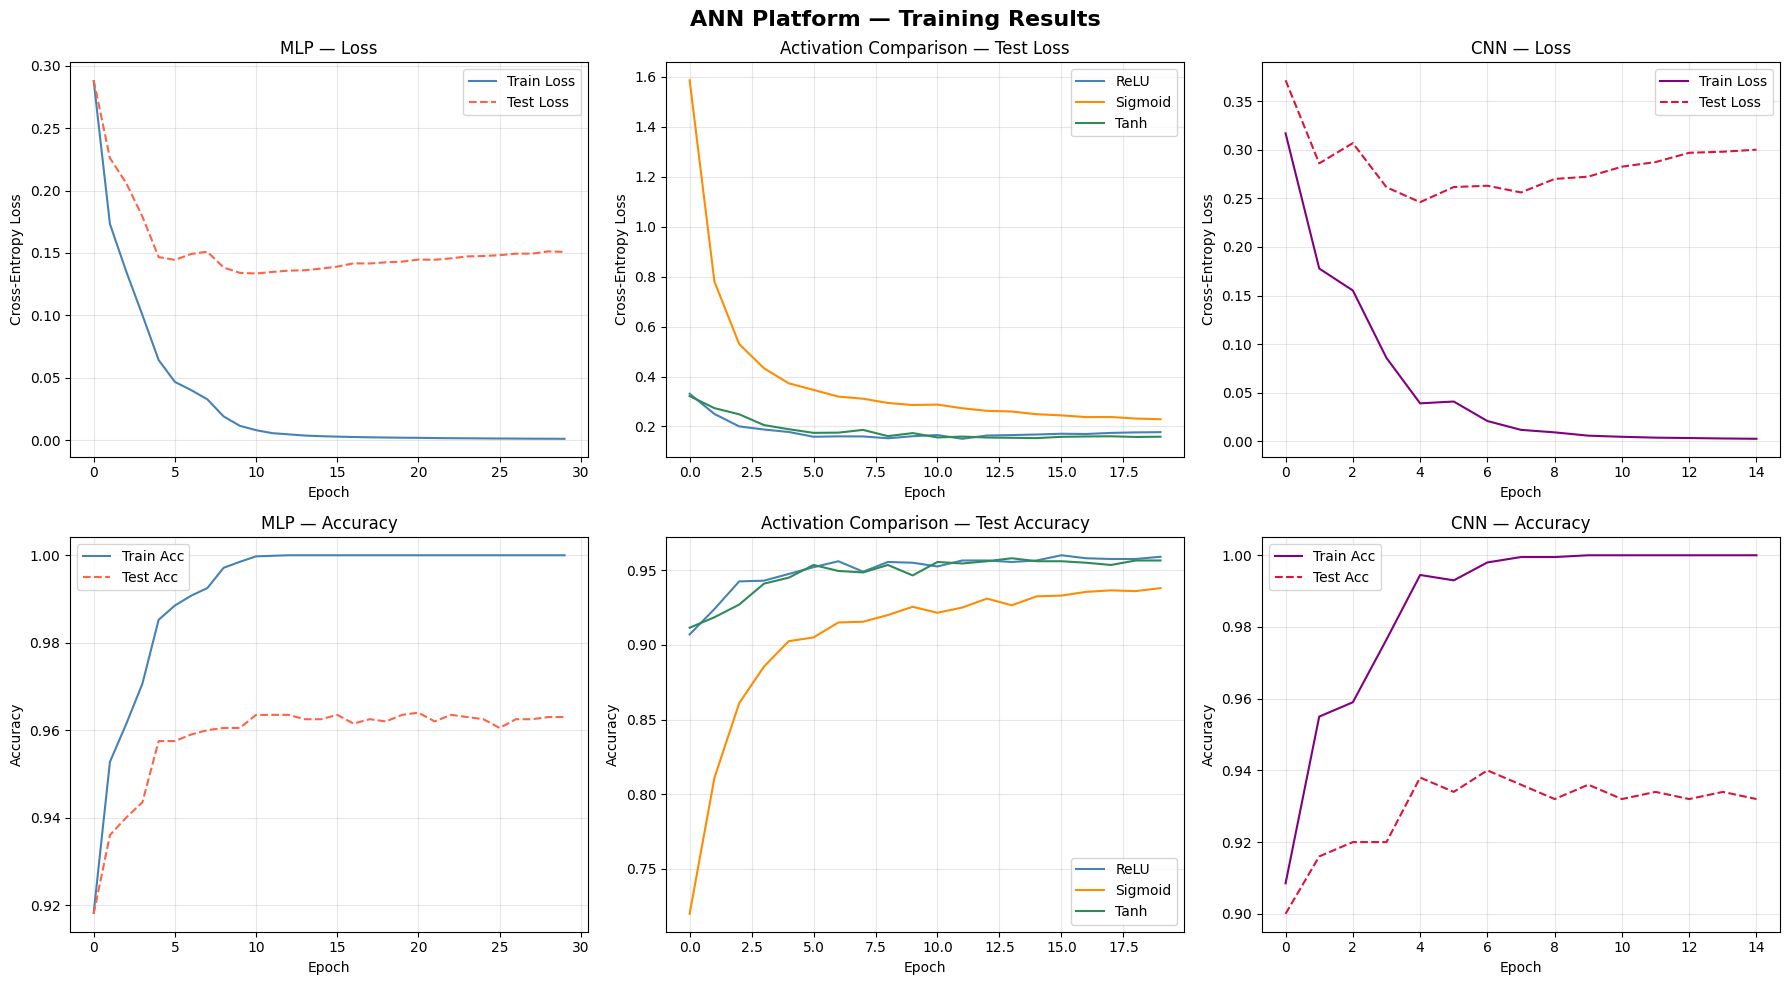

Plot saved to ann_results.png


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ANN Platform — Training Results', fontsize=16, fontweight='bold')

# --- MLP Loss ---
ax = axes[0, 0]
ax.plot(history_mlp['train_loss'], label='Train Loss', color='steelblue')
ax.plot(history_mlp['test_loss'],  label='Test Loss',  color='tomato', linestyle='--')
ax.set_title('MLP — Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# --- MLP Accuracy ---
ax = axes[1, 0]
ax.plot(history_mlp['train_acc'], label='Train Acc', color='steelblue')
ax.plot(history_mlp['test_acc'],  label='Test Acc',  color='tomato', linestyle='--')
ax.set_title('MLP — Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Activation Comparison: Loss ---
colors = {'ReLU': 'steelblue', 'Sigmoid': 'darkorange', 'Tanh': 'seagreen'}
ax = axes[0, 1]
for name, hist in histories_act.items():
    ax.plot(hist['test_loss'], label=name, color=colors[name])
ax.set_title('Activation Comparison — Test Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Activation Comparison: Accuracy ---
ax = axes[1, 1]
for name, hist in histories_act.items():
    ax.plot(hist['test_acc'], label=name, color=colors[name])
ax.set_title('Activation Comparison — Test Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# --- CNN Loss ---
ax = axes[0, 2]
ax.plot(history_cnn['train_loss'], label='Train Loss', color='purple')
ax.plot(history_cnn['test_loss'],  label='Test Loss',  color='crimson', linestyle='--')
ax.set_title('CNN — Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# --- CNN Accuracy ---
ax = axes[1, 2]
ax.plot(history_cnn['train_acc'], label='Train Acc', color='purple')
ax.plot(history_cnn['test_acc'],  label='Test Acc',  color='crimson', linestyle='--')
ax.set_title('CNN — Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ann_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to ann_results.png')

## 19. Final Summary Table

In [19]:
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'{"Model":<30} {"Test Acc":>10} {"Test Loss":>12}')
print('-' * 60)
print(f'{"MLP (ReLU, 784→256→128→10)":<30} '
      f'{history_mlp["test_acc"][-1]:>10.4f} '
      f'{history_mlp["test_loss"][-1]:>12.4f}')
for name, hist in histories_act.items():
    print(f'{f"MLP ({name}, 784→128→64→10)":<30} '
          f'{hist["test_acc"][-1]:>10.4f} '
          f'{hist["test_loss"][-1]:>12.4f}')
print(f'{"CNN (Conv2D→ReLU→FC→10)":<30} '
      f'{history_cnn["test_acc"][-1]:>10.4f} '
      f'{history_cnn["test_loss"][-1]:>12.4f}')
print('=' * 60)
print('Note: CNN trained on only 2000 samples for speed.')

FINAL RESULTS SUMMARY
Model                            Test Acc    Test Loss
------------------------------------------------------------
MLP (ReLU, 784→256→128→10)         0.9630       0.1509
MLP (ReLU, 784→128→64→10)          0.9590       0.1774
MLP (Sigmoid, 784→128→64→10)       0.9380       0.2290
MLP (Tanh, 784→128→64→10)          0.9565       0.1591
CNN (Conv2D→ReLU→FC→10)            0.9320       0.3002
Note: CNN trained on only 2000 samples for speed.


## 20. Visualize Conv1D Filters
Demonstrate Conv1D on synthetic 1D signal data.

Epoch   1/25 | Train Loss: 0.0410 Acc: 0.9950 | Test  Loss: 0.0395 Acc: 1.0000
Epoch   5/25 | Train Loss: 0.0059 Acc: 1.0000 | Test  Loss: 0.0053 Acc: 1.0000
Epoch  10/25 | Train Loss: 0.0027 Acc: 1.0000 | Test  Loss: 0.0024 Acc: 1.0000
Epoch  15/25 | Train Loss: 0.0017 Acc: 1.0000 | Test  Loss: 0.0015 Acc: 1.0000
Epoch  20/25 | Train Loss: 0.0012 Acc: 1.0000 | Test  Loss: 0.0011 Acc: 1.0000
Epoch  25/25 | Train Loss: 0.0009 Acc: 1.0000 | Test  Loss: 0.0008 Acc: 1.0000

Conv1D Sin/Cos Test Accuracy: 1.0000


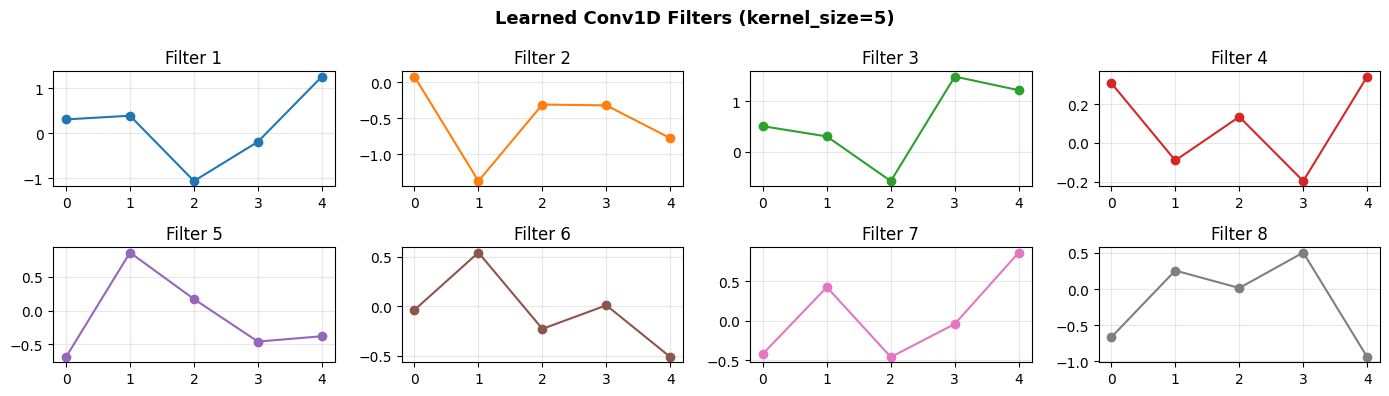

Learned Conv1D filters plotted.


In [20]:
# Synthetic 1D classification: sin vs cos
np.random.seed(7)
N, L = 500, 32
t = np.linspace(0, 2*np.pi, L)

# Class 0: sine-like, Class 1: cosine-like
X_1d = np.zeros((N, L, 1))
y_1d = np.zeros((N, 2))
for i in range(N):
    freq  = np.random.uniform(0.8, 1.2)
    phase = np.random.uniform(0, 0.5)
    noise = np.random.randn(L) * 0.1
    if i < N // 2:
        X_1d[i, :, 0] = np.sin(freq * t + phase) + noise
        y_1d[i, 0]    = 1
    else:
        X_1d[i, :, 0] = np.cos(freq * t + phase) + noise
        y_1d[i, 1]    = 1

X1_tr, X1_te = X_1d[:400], X_1d[400:]
y1_tr, y1_te = y_1d[:400], y_1d[400:]

# Build 1D CNN
cnn1d = Sequential([
    Conv1D(1, 8, kernel_size=5, stride=1, padding='valid'),  # (N,32,1) → (N,28,8)
    ReLU(),
    Flatten(),           # → (N, 224)
    Linear(28*8, 32),
    ReLU(),
    Linear(32, 2)
])

opt1d  = SGD(lr=0.01, momentum=0.9)
loss1d = CrossEntropyLoss()

hist1d = train(
    cnn1d, opt1d, loss1d,
    X1_tr, y1_tr, X1_te, y1_te,
    epochs=25, batch_size=32, print_every=5
)

print(f'\nConv1D Sin/Cos Test Accuracy: {hist1d["test_acc"][-1]:.4f}')

# Plot learned filters
fig, axes = plt.subplots(2, 4, figsize=(14, 4))
fig.suptitle('Learned Conv1D Filters (kernel_size=5)', fontsize=13, fontweight='bold')
filters = cnn1d.layers[0].W[:, 0, :]  # shape (5, 8)
for i, ax in enumerate(axes.flat):
    ax.plot(filters[:, i], marker='o', color=f'C{i}')
    ax.set_title(f'Filter {i+1}')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('conv1d_filters.png', dpi=120)
plt.show()
print('Learned Conv1D filters plotted.')

## Summary

This notebook implements a **complete ANN platform from scratch** using only NumPy:

| Component | Details |
|---|---|
| **Linear Layer** | Forward/backward, He init, bias |
| **Conv1D** | Valid & same padding, any kernel/stride |
| **Conv2D** | Valid & same padding, square or rectangular kernels |
| **Activations** | ReLU, Sigmoid, Tanh, Softmax |
| **Loss** | Cross-Entropy (+ Softmax), MSE |
| **Optimizer** | SGD with momentum |
| **Backprop** | Numerically verified via gradient check |
| **Evaluation** | MNIST accuracy & loss plots |

No PyTorch, TensorFlow, or autograd libraries were used.